In [1]:
# ------------- 0) Imports & Setup -------------
import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             precision_recall_fscore_support, roc_auc_score)

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


In [2]:
# PREPROCESSING
# List of CSV files
csv_files = [
    "Monday-WorkingHours.pcap_ISCX",
    "Tuesday-WorkingHours.pcap_ISCX",
    "Wednesday-workingHours.pcap_ISCX",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX",
    "Friday-WorkingHours-Morning.pcap_ISCX",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX"
]

combined_csv = []

for file in csv_files:
    path = f"{file}.csv"
    df = pd.read_csv(path, low_memory=False)

    # Cleaning of the data by removing repeated rows, replacing infinite values with NaN, and removing any rows that have missing values
    df = df.drop_duplicates()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df = df.dropna(how='any')

    # Removing spaces in column names if the space occurs in the beginning or at the ending (but keep internal spaces)
    df.columns = df.columns.str.strip()

    # Adding the cleaned DataFrame to the list
    combined_csv.append(df)

# Concatinating the CSV files
data = pd.concat(combined_csv, ignore_index=True)

# shape to check count of rows and columns in the concatinated table
print("Number of rows and columns", data.shape)
print("First 5 rows:")
display(data.head())

# showing summary statistics like mean, min, max for all the columns
print("\nStatistics of Numeric features")
display(data.describe().transpose())


Number of rows and columns (2572640, 79)
First 5 rows:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.000000,0.000000,0,0,0.0,0.000000,3.000000e+06,5.000000e+05,4.0,0.000000,4,4,4,4.0,0.000000,4,4,0,0.000000,0.000000,0,0,0,0,0,0,40,0,5.000000e+05,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.000000,6.000000,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.000000,0.000000,0,0,0.0,0.000000,1.200000e+07,2.000000e+06,1.0,0.000000,1,1,1,1.0,0.000000,1,1,0,0.000000,0.000000,0,0,0,0,0,0,40,0,2.000000e+06,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.000000,6.000000,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49486,3,2,0,12,0,6,6,6.000000,0.000000,0,0,0.0,0.000000,4.000000e+06,6.666667e+05,3.0,0.000000,3,3,3,3.0,0.000000,3,3,0,0.000000,0.000000,0,0,0,0,0,0,40,0,6.666667e+05,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.000000,6.000000,0.0,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49486,1,2,0,12,0,6,6,6.000000,0.000000,0,0,0.0,0.000000,1.200000e+07,2.000000e+06,1.0,0.000000,1,1,1,1.0,0.000000,1,1,0,0.000000,0.000000,0,0,0,0,0,0,40,0,2.000000e+06,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.000000,6.000000,0.0,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,609,7,4,484,414,233,0,69.142857,111.967895,207,0,103.5,119.511506,1.474548e+06,1.806240e+04,60.9,115.194956,381,2,609,101.5,177.089525,460,2,467,155.666667,263.560872,460,3,0,0,0,0,164,104,1.149425e+04,6568.144499,0,233,74.833333,107.527445,11562.151515,0,0,0,1,0,0,0,0,0,81.636364,69.142857,103.5,164,0,0,0,0,0,0,7,484,4,414,8192,2053,5,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN



Statistics of Numeric features


,count,mean,std,min,25%,50%,75%,max
Destination Port,2572640.0,8.522897e+03,1.886345e+04,0.0,53.0,80.0,443.00,65535.0
Flow Duration,2572640.0,1.625736e+07,3.495376e+07,-13.0,200.0,48854.0,5225583.25,119999998.0
Total Fwd Packets,2572640.0,1.011604e+01,7.863759e+02,1.0,2.0,2.0,5.00,219759.0
Total Backward Packets,2572640.0,1.137032e+01,1.046220e+03,0.0,1.0,2.0,5.00,291922.0
Total Length of Fwd Packets,2572640.0,6.013675e+02,1.048137e+04,0.0,12.0,66.0,325.00,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2572640.0,6.414441e+04,6.050393e+05,0.0,0.0,0.0,0.00,110000000.0
Idle Mean,2572640.0,9.149207e+06,2.463152e+07,0.0,0.0,0.0,0.00,120000000.0
Idle Std,2572640.0,5.543927e+05,4.825464e+06,0.0,0.0,0.0,0.00,76900000.0
Idle Max,2572640.0,9.567018e+06,2.539512e+07,0.0,0.0,0.0,0.00,120000000.0


In [3]:
# Using normalization to clean the label names
def normalize_label(s):
    if not isinstance(s, str):  # If it is not a string, then return it as it is
        return s
    t = s.strip().lower()       # Remove extra spaces and make lowercase
    t = t.replace('—', '-').replace('–', '-').replace('�', '')  # Replace dash characters
    t = t.replace(':', '').replace('  ', ' ')  # Remove colons and double spaces

    #Fixing the column labels
    t = t.replace('web attack  brute force', 'web attack brute force')
    t = t.replace('web attack  xss', 'web attack xss')
    t = t.replace('web attack  sql injection', 'web attack sql injection')
    t = t.replace('dos slowhttptest', 'dos slowhttptest')
    t = t.replace('dos slowloris', 'dos slowloris')
    return t

data['Label'] = data['Label'].astype(str).apply(normalize_label)

# Map the labels to consistent forms for grouping
canonical = {
    'benign': 'BENIGN',
    'dos hulk': 'DoS Hulk',
    'portscan': 'PortScan',
    'ddos': 'DDoS',
    'dos goldeneye': 'DoS GoldenEye',
    'ftp-patator': 'FTP-Patator',
    'ssh-patator': 'SSH-Patator',
    'dos slowloris': 'DoS slowloris',
    'dos slowhttptest': 'DoS Slowhttptest',
    'bot': 'Bot',
    'web attack brute force': 'Web Attack : Brute Force',
    'web attack xss': 'Web Attack : XSS',
    'web attack sql injection': 'Web Attack : Sql Injection',
    'infiltration': 'Infiltration',
    'heartbleed': 'Heartbleed'
}

# Replacing each label with its new version
data['Label'] = data['Label'].map(lambda s: canonical.get(s, s))

print("Label counts (cleaned):")
display(data['Label'].value_counts())

# Binary Attack column: 0 = BENIGN, 1 = attack
data['Attack'] = np.where(data['Label'] == 'BENIGN', 0, 1)

# Grouped categories
attack_group = {
    'BENIGN': 'benign', 
    'DoS Hulk': 'dos',
    'PortScan': 'ports', 
    'DDoS': 'ddos',
    'DoS GoldenEye': 'dos', 
    'FTP-Patator': 'brute_force',
    'SSH-Patator': 'brute_force', 
    'DoS slowloris': 'dos', 
    'DoS Slowhttptest': 'dos',
    'Bot': 'botnet',
    'Web Attack : Brute Force': 'web_attack', 
    'Web Attack : XSS': 'web_attack',
    'Web Attack : Sql Injection': 'web_attack',
    'Infiltration': 'infiltration',
    'Heartbleed': 'heartbleed'
}

# If label is not present above, then marking it as other
data['Label_Category'] = data['Label'].map(lambda x: attack_group.get(x, 'other'))

#Showing how many labels fall under each attack category
print("\nCounts per Label_Category:")
display(data['Label_Category'].value_counts())


Label counts (cleaned):


Label
BENIGN                        2146899
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack : Brute Force         1470
Web Attack : XSS                  652
Infiltration                       36
Web Attack : Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


Counts per Label_Category:


Label_Category
benign          2146899
dos              193745
ddos             128014
ports             90694
brute_force        9150
web_attack         2143
botnet             1948
infiltration         36
heartbleed           11
Name: count, dtype: int64

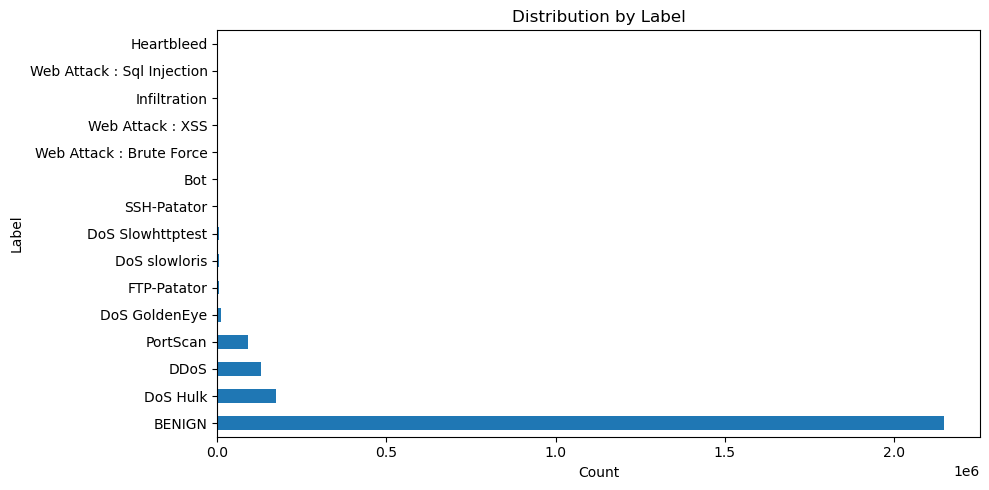

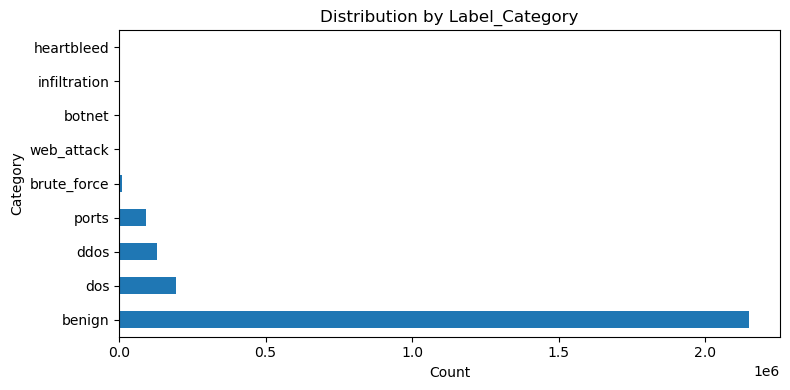

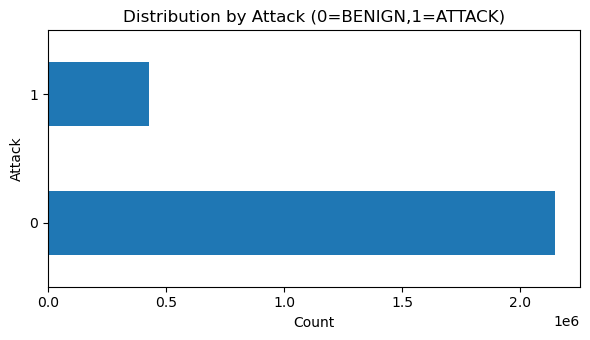

In [4]:
# STATISTICAL ANALYSIS

# Plot to show how many times each specific label appears 
plt.figure(figsize=(10,5))
data['Label'].value_counts().plot(kind='barh')
plt.title('Distribution by Label')
plt.xlabel('Count'); plt.ylabel('Label')
plt.tight_layout(); plt.show()    #Adjust the layout so that it doesn't get cut off form the frame

# Plot to show how many times each grouped category appears
plt.figure(figsize=(8,4))
data['Label_Category'].value_counts().plot(kind='barh')
plt.title('Distribution by Label_Category')
plt.xlabel('Count'); plt.ylabel('Category')
plt.tight_layout(); plt.show()


# Plot to show how many Benign vs attack rows are present, this is to check if the dataset is balanced or skewed 
plt.figure(figsize=(6,3.5))
data['Attack'].value_counts().sort_index().plot(kind='barh')
plt.title('Distribution by Attack (0=BENIGN,1=ATTACK)')
plt.xlabel('Count'); plt.ylabel('Attack')
plt.tight_layout(); plt.show()


In [5]:
#  DIVIDING THE CLEANED DATA INTO TRAINING, TESTING AND DEVELOPMENT DATA

# Columns to treat as labels
attacks = ['Label', 'Label_Category', 'Attack']

# Separate features xs labels ys ; xs to remove except the label column and ys is the names of columns inted to predict
xs = data.drop(columns=attacks)
ys = data[attacks].copy()

# Converting any leftover columns on xs to numbers to give numeric input to the ML models
for col in xs.select_dtypes(include=['object']).columns:
    xs[col] = pd.factorize(xs[col])[0]

# Splitting the data into 70% training, 30% temporary (testing and development)
x_train, x_temp, y_train, y_temp = train_test_split(
    xs, ys, test_size=0.30, random_state=0, stratify=ys['Label']
)

# Splitting the Temporary data into 15% development and 15% testing (split temp 50/50)
x_test, x_development, y_test, y_development = train_test_split(
    x_temp, y_temp, test_size=0.50, random_state=0, stratify=y_temp['Label']
)

#Showing the number of rows and columns in each split
print("Shapes:")
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_development:", x_development.shape, "y_development:", y_development.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)


Shapes:
x_train: (1800848, 78) y_train: (1800848, 3)
x_development: (385896, 78) y_development: (385896, 3)
x_test: (385896, 78) y_test: (385896, 3)


In [6]:
# REMOVING FEATURES WHICH SHOW SAME VALUE FOR MOST OBSERVATIONS 

# Counting how many unique values are there in each column of training data and identifying columns which have only one unique value
unique_counts = x_train.nunique()
constant_cols = unique_counts[unique_counts <= 1].index.tolist()

# If any columns are same, then remove them from all the data sets
if constant_cols:
    x_train = x_train.drop(columns=constant_cols)
    x_development = x_development.drop(columns=constant_cols, errors='ignore')
    x_test = x_test.drop(columns=constant_cols, errors='ignore')
    print(f"Dropped {len(constant_cols)} constant features.")
else:
    print("No constant features found.")


Dropped 8 constant features.


In [7]:
# MinMax scaling (training)

scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_dev_scaled   = scaler.transform(x_development)
x_test_scaled  = scaler.transform(x_test)

# Quick check
print(pd.Series(x_train_scaled.flatten()).describe())


count    1.260594e+08
mean     1.029127e-01
std      2.729648e-01
min      0.000000e+00
25%      0.000000e+00
50%      3.513679e-06
75%      9.257923e-03
max      1.000000e+00
dtype: float64


In [8]:
# FILTER FEATURE SELECTION TO FIT ON TRAINING ONLY because the model should learn only training data

K = min(40, x_train.shape[1])  # keep top 40 or fewer if not enough features

# Creating a feature selector using ANOVA F-test 
# selector = SelectKBest(score_func=mutual_info_classif, k=K)
selector = SelectKBest(score_func=f_classif, k=K)

# Fitting the selector on training data and transforming all the sets
x_train_fs = selector.fit_transform(x_train_scaled, y_train['Attack'])
x_dev_fs   = selector.transform(x_dev_scaled)
x_test_fs  = selector.transform(x_test_scaled)

# Get the names of the selected features 
selected_mask = selector.get_support()
selected_features = x_train.columns[selected_mask].tolist()

# Printing how many features were selected and show the first few 
print(f"Selected {len(selected_features)} features:")
print(selected_features[:20], "...")


Selected 40 features:
['Destination Port', 'Flow Duration', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd PSH Flags'] ...


RF (fast) trained in 99.31s

Top 20 RF importances:


,Feature,Importance
25,Packet Length Variance,0.097818
24,Packet Length Std,0.090604
5,Bwd Packet Length Max,0.068949
23,Packet Length Mean,0.051300
2,Fwd Packet Length Max,0.047098
8,Bwd Packet Length Std,0.043033
22,Max Packet Length,0.039755
33,Avg Fwd Segment Size,0.038346
7,Bwd Packet Length Mean,0.037472
16,Fwd IAT Max,0.036708


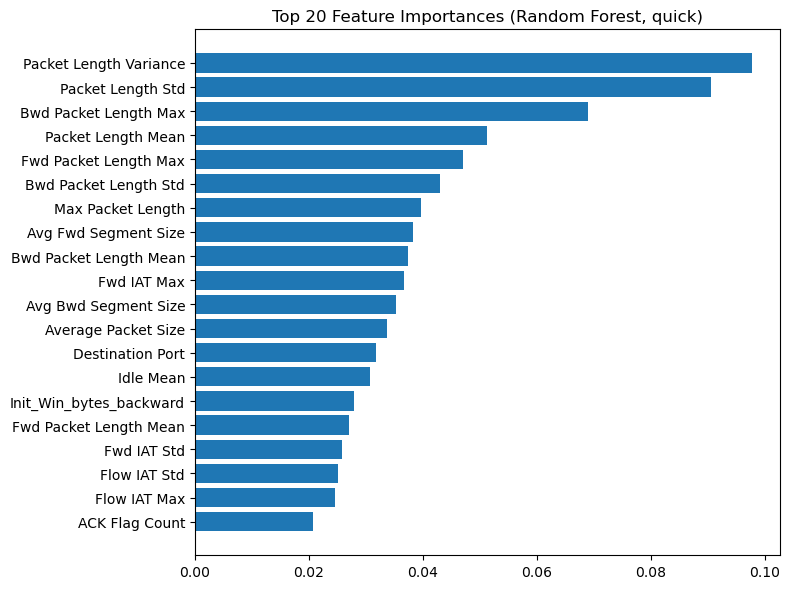

In [9]:
# RANDOM-FOREST FEATURE IMPORTANCE

# Train quick RF on TRAINING data (selected features)
rf_fast = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# Measuring how long will it take to train the model
t0 = time.time()
rf_fast.fit(x_train_fs, y_train['Label'])
t1 = time.time()
print(f"RF (fast) trained in {t1 - t0:.2f}s")

# Getting feature importance scores from the trained model 
# These scores show which features had the most impact on prediction
fi = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf_fast.feature_importances_
}).sort_values('Importance', ascending=False)

# Showing the top 20 most important features
print("\nTop 20 RF importances:")
display(fi.head(20))

# Ploting the top 20 feature importances as a bar chart
plt.figure(figsize=(8,6))
plt.barh(fi.head(20)['Feature'][::-1], fi.head(20)['Importance'][::-1])
plt.title("Top 20 Feature Importances (Random Forest, quick)")
plt.tight_layout(); plt.show()


RF train time: 344.55s

Latency test (10% of test data):
Number of samples: 38589
Total inference time: 0.3295s
Latency per sample: 0.000009s
Throughput: 117117.47 samples/s
RF train time: 344.55s | inference time (test): 3.06s

Classification report (per-class):
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    322035
                       Bot       0.68      0.60      0.64       292
                      DDoS       1.00      1.00      1.00     19202
             DoS GoldenEye       1.00      0.99      1.00      1543
                  DoS Hulk       1.00      0.99      1.00     25927
          DoS Slowhttptest       0.99      0.99      0.99       784
             DoS slowloris       1.00      1.00      1.00       808
               FTP-Patator       1.00      1.00      1.00       889
                Heartbleed       0.00      0.00      0.00         1
              Infiltration       1.00      0.83      0.

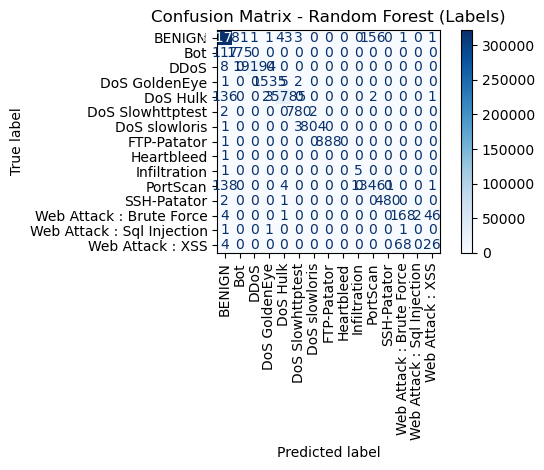

Accuracy: 0.9978 | Macro Precision: 0.7803 | Macro Recall: 0.7612 | Macro F1: 0.7697


In [10]:
# SUPERVISED RANDOM FOREST
from sklearn.model_selection import train_test_split
# Creating a Random forest classifier with 200 trees
rf = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_split=2,
    n_jobs=-1, random_state=42
)

# Training the model and measuring training time
t0 = time.time()
rf.fit(x_train_fs, y_train['Label'])
train_time = time.time() - t0
print(f"RF train time: {train_time:.2f}s")

# --- LATENCY / THROUGHPUT ON 10% TEST DATA ---
sample_size = int(0.10 * len(x_test_fs))
x_sample = x_test_fs[:sample_size]
y_sample = y_test[:sample_size]

start_time = time.time()
y_pred_sample = rf.predict(x_sample)
end_time = time.time()

total_time = end_time - start_time
latency_per_sample = total_time / sample_size
throughput = sample_size / total_time

print(f"\nLatency test (10% of test data):")
print(f"Number of samples: {sample_size}")
print(f"Total inference time: {total_time:.4f}s")
print(f"Latency per sample: {latency_per_sample:.6f}s")
print(f"Throughput: {throughput:.2f} samples/s")


# Make predictions on the testing data and measure inference time
t0 = time.time()
y_pred_test = rf.predict(x_test_fs)
infer_time = time.time() - t0

# Printing training and inference time
print(f"RF train time: {train_time:.2f}s | inference time (test): {infer_time:.2f}s")

# Printing detailed classification metrics for each class
print("\nClassification report (per-class):")
print(classification_report(y_test['Label'], y_pred_test, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test['Label'], y_pred_test, labels=rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(xticks_rotation=90, cmap='Blues')
plt.title("Confusion Matrix - Random Forest (Labels)")
plt.tight_layout(); plt.show()

# Macro metrics (quality)
acc = accuracy_score(y_test['Label'], y_pred_test)
prec, rec, f1, _ = precision_recall_fscore_support(y_test['Label'], y_pred_test, average='macro', zero_division=0)
print(f"Accuracy: {acc:.4f} | Macro Precision: {prec:.4f} | Macro Recall: {rec:.4f} | Macro F1: {f1:.4f}")


IsolationForest train time: 3.47s

Isolation Forest latency test (10% of test data):
Number of samples: 38589
Total inference time: 0.4839s
Latency per sample: 0.000013s
Throughput: 79749.50 samples/s
IsolationForest train time: 3.47s | inference time: 5.49s

Isolation Forest vs. Attack (0=BENIGN,1=ATTACK):
              precision    recall  f1-score   support

           0       0.90      0.94      0.92    322035
           1       0.60      0.47      0.53     63861

    accuracy                           0.86    385896
   macro avg       0.75      0.71      0.72    385896
weighted avg       0.85      0.86      0.85    385896



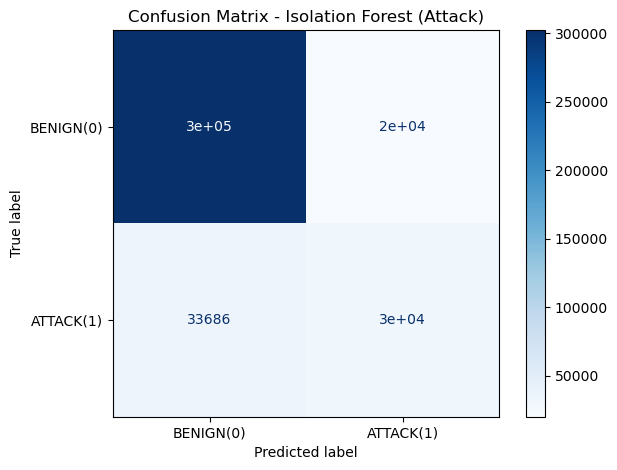

Accuracy: 0.8610 | Precision: 0.6021 | Recall: 0.4725 | F1: 0.5295


In [11]:
# UNSUPERVISED ISOLATION FOREST 
from sklearn.model_selection import train_test_split
# Create an Isolation Forest Model for anomaly detection
iso = IsolationForest(
    n_estimators=200, contamination='auto', random_state=42, n_jobs=-1
)

# Training the model using the features only (no labels)
t0 = time.time()
iso.fit(x_train_fs)   # unsupervised: only features
train_time = time.time() - t0
print(f"IsolationForest train time: {train_time:.2f}s")

# --- LATENCY / THROUGHPUT ON 10% TEST DATA ---
sample_size = int(0.10 * len(x_test_fs))
x_sample = x_test_fs[:sample_size]
y_sample = y_test[:sample_size]

start_time = time.time()
iso_pred_sample = iso.predict(x_sample)
end_time = time.time()

total_time = end_time - start_time
latency_per_sample = total_time / sample_size
throughput = sample_size / total_time

print(f"\nIsolation Forest latency test (10% of test data):")
print(f"Number of samples: {sample_size}")
print(f"Total inference time: {total_time:.4f}s")
print(f"Latency per sample: {latency_per_sample:.6f}s")
print(f"Throughput: {throughput:.2f} samples/s")

 
# Predictions on the test data
t0 = time.time()
iso_pred = iso.predict(x_test_fs)  # 1=inlier, -1=outlier
infer_time = time.time() - t0

# Showing how long training and prediction works
print(f"IsolationForest train time: {train_time:.2f}s | inference time: {infer_time:.2f}s")

# Map predictions to 0/1 binary format (0=benign, 1=attack)
iso_attack_pred = np.where(iso_pred == -1, 1, 0)

# Compare predictions to actual attack labels (0 = benign, 1 = attack)
print("\nIsolation Forest vs. Attack (0=BENIGN,1=ATTACK):")
print(classification_report(y_test['Attack'], iso_attack_pred, zero_division=0))

# Confusion matrix to visualize correct vs incorrect predictions
cm = confusion_matrix(y_test['Attack'], iso_attack_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BENIGN(0)','ATTACK(1)'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Isolation Forest (Attack)")
plt.tight_layout(); plt.show()

#Printing overall performance metrics
acc = accuracy_score(y_test['Attack'], iso_attack_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test['Attack'], iso_attack_pred, average='binary', zero_division=0)
print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")


In [12]:
'''# ------------- 11) Unsupervised: One-Class SVM -------------

# gamma='scale' works reasonably well; you may try nu in [0.01..0.5]
oc = OneClassSVM(kernel='rbf', gamma='scale', nu=0.5)

t0 = time.time()
oc.fit(x_train_fs)   # unsupervised
train_time = time.time() - t0

t0 = time.time()
oc_pred = oc.predict(x_test_fs)  # 1=inlier, -1=outlier
infer_time = time.time() - t0

print(f"One-Class SVM train time: {train_time:.2f}s | inference time: {infer_time:.2f}s")

oc_attack_pred = np.where(oc_pred == -1, 1, 0)

print("\nOne-Class SVM vs. Attack (0=BENIGN,1=ATTACK):")
print(classification_report(y_test['Attack'], oc_attack_pred, zero_division=0))

cm = confusion_matrix(y_test['Attack'], oc_attack_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BENIGN(0)','ATTACK(1)'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - One-Class SVM (Attack)")
plt.tight_layout(); plt.show()

acc = accuracy_score(y_test['Attack'], oc_attack_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test['Attack'], oc_attack_pred, average='binary', zero_division=0)
print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
'''

'# ------------- 11) Unsupervised: One-Class SVM -------------\n\n# gamma=\'scale\' works reasonably well; you may try nu in [0.01..0.5]\noc = OneClassSVM(kernel=\'rbf\', gamma=\'scale\', nu=0.5)\n\nt0 = time.time()\noc.fit(x_train_fs)   # unsupervised\ntrain_time = time.time() - t0\n\nt0 = time.time()\noc_pred = oc.predict(x_test_fs)  # 1=inlier, -1=outlier\ninfer_time = time.time() - t0\n\nprint(f"One-Class SVM train time: {train_time:.2f}s | inference time: {infer_time:.2f}s")\n\noc_attack_pred = np.where(oc_pred == -1, 1, 0)\n\nprint("\nOne-Class SVM vs. Attack (0=BENIGN,1=ATTACK):")\nprint(classification_report(y_test[\'Attack\'], oc_attack_pred, zero_division=0))\n\ncm = confusion_matrix(y_test[\'Attack\'], oc_attack_pred, labels=[0,1])\ndisp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[\'BENIGN(0)\',\'ATTACK(1)\'])\ndisp.plot(cmap=\'Blues\')\nplt.title("Confusion Matrix - One-Class SVM (Attack)")\nplt.tight_layout(); plt.show()\n\nacc = accuracy_score(y_test[\'A

Naive Bayes train time: 1.63s

Naive Bayes latency test (10% of test data):
Number of samples: 38589
Total inference time: 0.0405s
Latency per sample: 0.000001s
Throughput: 953501.37 samples/s
Naive Bayes train time: 1.63s | inference time: 0.36s

Naive Bayes vs. Attack (0=BENIGN,1=ATTACK):
              precision    recall  f1-score   support

           0       0.92      0.92      0.92    322035
           1       0.59      0.62      0.60     63861

    accuracy                           0.87    385896
   macro avg       0.76      0.77      0.76    385896
weighted avg       0.87      0.87      0.87    385896



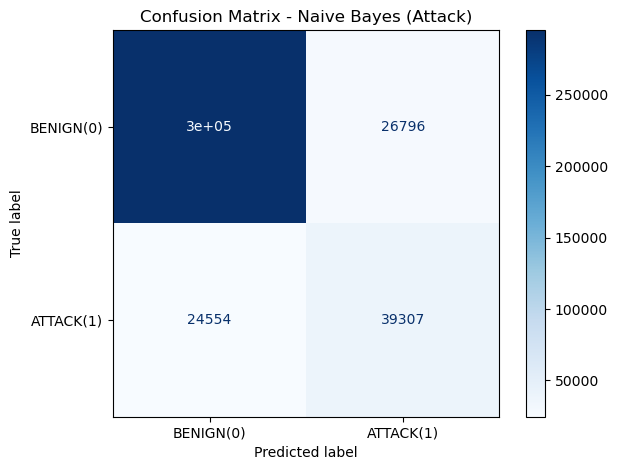

Accuracy: 0.8669 | Precision: 0.5946 | Recall: 0.6155 | F1: 0.6049


In [13]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# --- Train Naive Bayes ---
nb = GaussianNB()

t0 = time.time()
nb.fit(x_train_fs, y_train['Attack'])  # supervised: features + binary labels
train_time = time.time() - t0
print(f"Naive Bayes train time: {train_time:.2f}s")

# --- LATENCY / THROUGHPUT ON 10% TEST DATA ---
sample_size = int(0.10 * len(x_test_fs))
x_sample = x_test_fs[:sample_size]
y_sample = y_test[:sample_size]

start_time = time.time()
nb_pred_sample = nb.predict(x_sample)
end_time = time.time()

total_time = end_time - start_time
latency_per_sample = total_time / sample_size
throughput = sample_size / total_time

print(f"\nNaive Bayes latency test (10% of test data):")
print(f"Number of samples: {sample_size}")
print(f"Total inference time: {total_time:.4f}s")
print(f"Latency per sample: {latency_per_sample:.6f}s")
print(f"Throughput: {throughput:.2f} samples/s")


# --- Predict ---
t0 = time.time()
nb_pred = nb.predict(x_test_fs)
infer_time = time.time() - t0

print(f"Naive Bayes train time: {train_time:.2f}s | inference time: {infer_time:.2f}s")

# Predictions are already 0/1 if 'Attack' is binary
nb_attack_pred = nb_pred

# --- Evaluate ---
print("\nNaive Bayes vs. Attack (0=BENIGN,1=ATTACK):")
print(classification_report(y_test['Attack'], nb_attack_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test['Attack'], nb_attack_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BENIGN(0)','ATTACK(1)'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes (Attack)")
plt.tight_layout()
plt.show()

# Accuracy, precision, recall, F1
acc = accuracy_score(y_test['Attack'], nb_attack_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test['Attack'], nb_attack_pred, average='binary', zero_division=0)
print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

